In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
import os

ticker = "AAPL"

if not os.path.exists('aapl_data.csv'):
    data = yf.download(ticker, start="2021-01-01", end="2026-01-24")
    data.to_csv('aapl_data.csv')
data = pd.read_csv('aapl_data.csv', skiprows=[1, 2], index_col=0, parse_dates=True).rename_axis('Date')
print(data.head())
print(data.dtypes)

                 Close        High         Low        Open     Volume
Date                                                                 
2021-01-04  125.974464  130.062961  123.394814  129.975354  143301900
2021-01-05  127.532005  128.242636  125.020496  125.468291   97664900
2021-01-06  123.239059  127.570927  123.024899  124.329329  155088000
2021-01-07  127.444359  128.135516  124.465598  124.952324  109578200
2021-01-08  128.544373  129.108977  126.772682  128.914274  105158200
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


though examples, gave prediction based on only closing price, but I thought that tking both the price and volume will give better result

In [3]:
df = data[['Close', 'Volume']].copy()
df.rename(columns={'Close': 'price'}, inplace=True)
df.dropna(inplace=True)

df=df.asfreq('B')      # business days, as arima expects regular frequency
df.ffill(inplace=True)          


df['log_volume'] = np.log(df['Volume'])
df['log_vol_lag1'] = df['log_volume'].shift(1) 
df.dropna(inplace=True)
print(df.head())

                 price       Volume  log_volume  log_vol_lag1
Date                                                         
2021-01-05  127.532005   97664900.0   18.397053     18.780464
2021-01-06  123.239059  155088000.0   18.859503     18.397053
2021-01-07  127.444359  109578200.0   18.512149     18.859503
2021-01-08  128.544373  105158200.0   18.470976     18.512149
2021-01-11  125.555870  100384500.0   18.424518     18.470976


In [4]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test  = df.iloc[train_size:]

y_train = train['price']
y_test  = test['price']

X_train = train[['log_vol_lag1']]
X_test  = test[['log_vol_lag1']]

In [5]:
model = ARIMA(
    y_train,
    exog=X_train,
    order=(5,1,0) #here 5 means, that prediction is based on last 5 days
)
fit = model.fit()

I have to assume the future volume as roughly equal to present volume, as arimax expected that.

also i will now test the accuracy, and for that i could use a rolling prediction, but then my cpu was taking too much time, so, forecasting over the test period only

In [6]:
pred = fit.forecast(
    steps=len(y_test),
    exog=X_test
)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 23.56729459135149
RMSE: 27.550242783181126


the logic to fit each time is because as market evolves with time, our model accuracy has to be based on prev 5 days always

In [7]:
final_model = ARIMA(
    df['price'],
    exog=df[['log_vol_lag1']],
    order=(5,1,0)
)
final_fit = final_model.fit()

last_log_vol = df['log_vol_lag1'].iloc[-1]
future_exog = np.full((7, 1), last_log_vol)

forecast = final_fit.get_forecast(
    steps=7,
    exog=future_exog
)

mean_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()

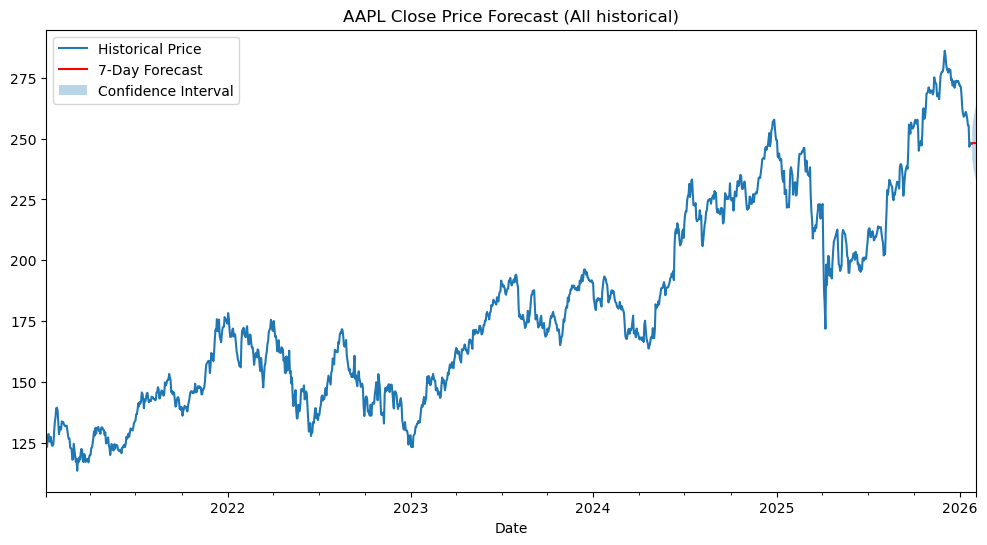

In [8]:
plt.figure(figsize=(12,6))

df['price'].plot(label='Historical Price')
mean_forecast.plot(color='red', label='7-Day Forecast')

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3,
    label='Confidence Interval'
)

plt.title(f"{ticker} Close Price Forecast (All historical)")
plt.legend()
plt.show()

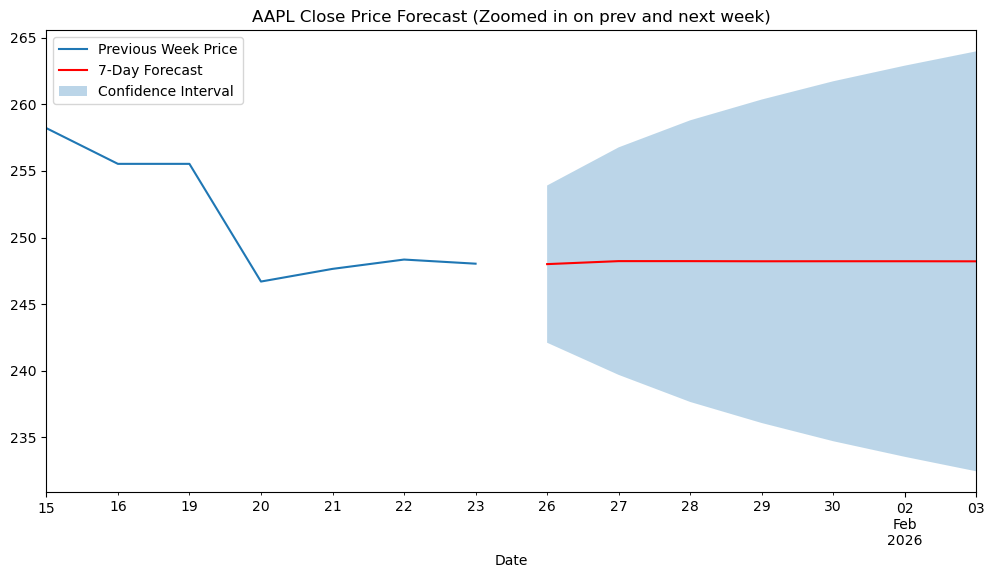

In [9]:
prev_week = df['price'].iloc[-7:]
plt.figure(figsize=(12,6))

prev_week.plot(label='Previous Week Price')
mean_forecast.plot(color='red', label='7-Day Forecast')

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3,
    label='Confidence Interval'
)
plt.title(f"{ticker} Close Price Forecast (Zoomed in on prev and next week)")
plt.legend()
plt.show()

but here I assumed the volume to be constant for next 7 days, which is crude, i could-

    * Train on volume and then insert the ARIMA of volume forecast of 7 days into my arimax
    Caveat:- while good, both price and volume are linked, variating price with a huge volume means that it is a market trend, otherwise an increase or decrease with a small volume is linked to market trend, also sharp decreasing prices can create buying frenzy/ selling panic
    so both are inherently linked values and training anyone alone, will lead to not error, but too high a confidence as none derive from the other and depend on each other

    * Or I can make train an vector autoregression (VAR), which predicts both at once, included in statsmodel but as it is not technicall not as good as ARIMA

    * I can make LSTM, which is a basic neural net method


In [10]:
#proceeding with VAR

df['log_close'] = np.log(df['price'])

df['ret'] = df['log_close'].diff()#return as log difference as cheaper vectorised calculation than percentage change
df['dlog_vol'] = df['log_volume'].diff()

var_df = df[['ret', 'dlog_vol']].dropna()
var_df = var_df.asfreq('B').ffill() #business day filling

In [11]:
from statsmodels.tsa.api import VAR

model = VAR(var_df)
fitv = model.fit(maxlags=5, ic='aic')#5 days as that is the trading week length
#forecast of next 7 days
forecast = fitv.forecast(
    var_df.values[-fitv.k_ar:],
    steps=7
)

now we have the difference predicted, but the difference of the log needs to be converted to a dataframe of prices with dates as index to plot

In [12]:
future_dates = pd.date_range(
    start=var_df.index[-1],
    periods=8,
    freq='B'
)[1:]
fc_df = pd.DataFrame(
    forecast,
    columns=var_df.columns,
    index=future_dates
)
print(fc_df.head(2))

                 ret  dlog_vol
2026-01-26  0.000526  0.179777
2026-01-27  0.001380  0.032553


In [13]:
last_price = df['price'].iloc[-1]

prices = []
price = last_price

for r in fc_df['ret']: #the log difference gain is added to last price, like gain eg. 1.2x gain
    price = price * np.exp(r)
    prices.append(price)


last_vol = df['Volume'].iloc[-1]

volumes = []
vol = last_vol

for dv in fc_df['dlog_vol']:
    vol = vol * np.exp(dv)
    volumes.append(vol)


final_forecast = pd.DataFrame(
    {
        'price': prices,
        'volume': volumes
    },
    index=fc_df.index
)

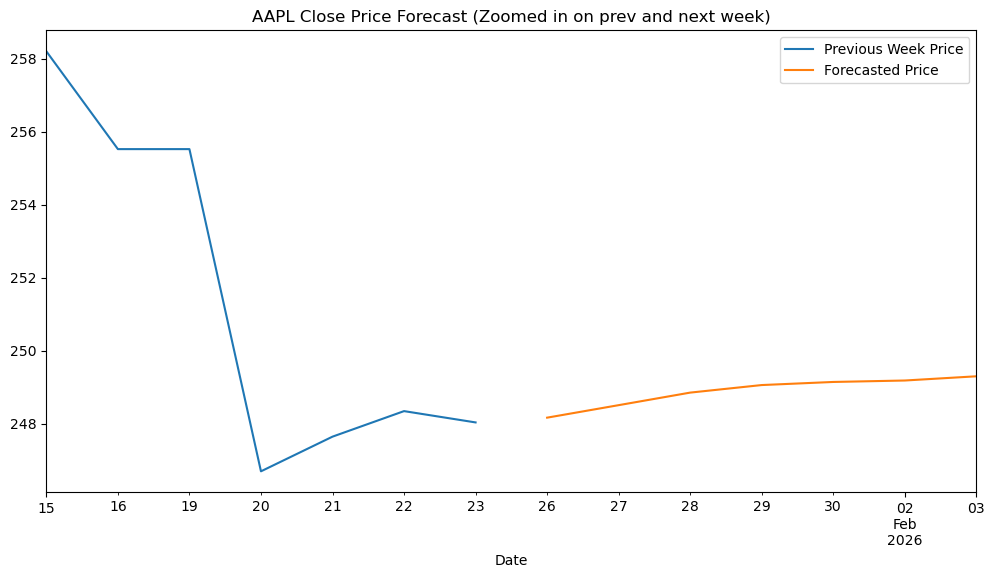

In [14]:
plt.figure(figsize=(12,6))
prev_week.plot(label='Previous Week Price')
final_forecast['price'].plot(label='Forecasted Price')
plt.title(f"{ticker} Close Price Forecast (Zoomed in on prev and next week)")
plt.legend()
plt.show()

# The way forward

I can insert the output of the VAR in the ARIMAX again, as the exogenous variable, like intially above, but this time instead of volume fix as last day known, we expand, for even more accuracy

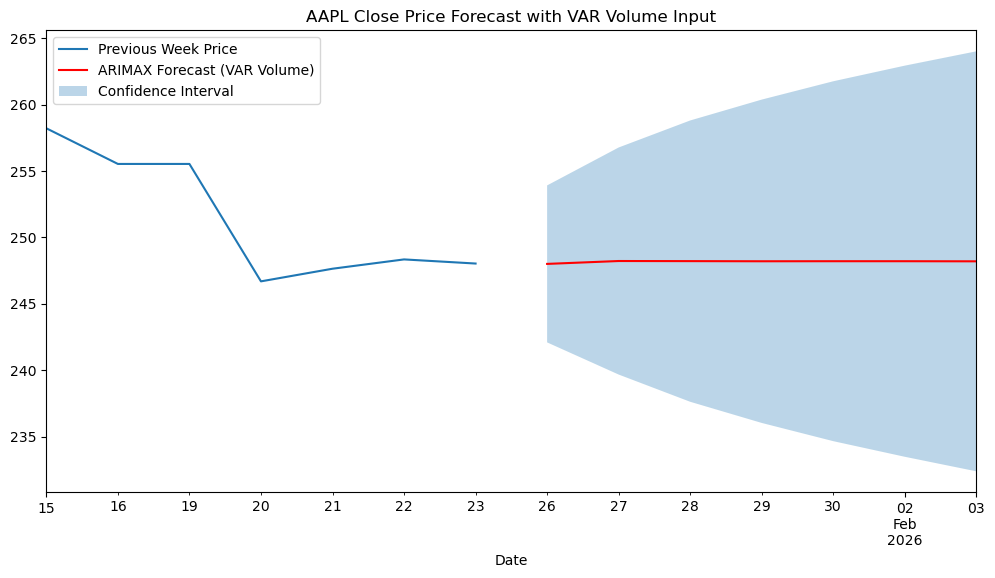

In [15]:
future_exog = final_forecast[['volume']].copy()
future_exog['log_volume'] = np.log(future_exog['volume'])
future_exog = future_exog[['log_volume']]

arimax_model = ARIMA(
    df['price'],
    exog=np.log(df['Volume']),
    order=(5, 1, 0) #like before
)
arimax_fit = arimax_model.fit()

# Forecast with VAR-predicted volume, but now we don't lag as we have the forecasted volume for the next 7 days directly
arimax_forecast = arimax_fit.get_forecast(
    steps=7,
    exog=future_exog.values
)

# Extract forecast and confidence intervals
mean_forecast = arimax_forecast.predicted_mean
conf_int = arimax_forecast.conf_int()

# Plotting
plt.figure(figsize=(12, 6))
prev_week.plot(label='Previous Week Price')
mean_forecast.plot(color='red', label='ARIMAX Forecast (VAR Volume)')
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.3,
    label='Confidence Interval'
)
plt.title(f"{ticker} Close Price Forecast with VAR Volume Input")
plt.legend()
plt.show()

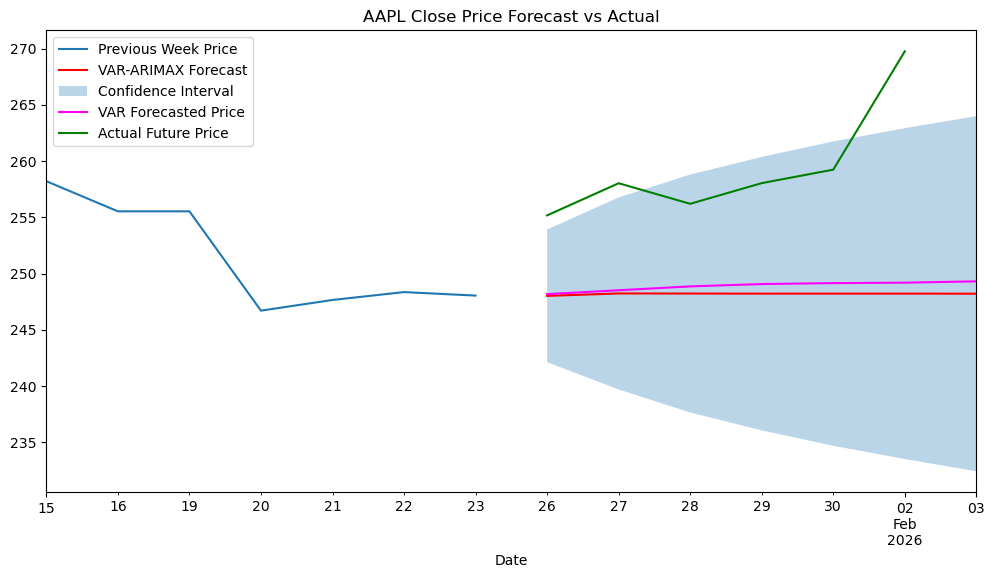

In [18]:
# verifying with actual f_data to see the performance of our VAR-ARIMAX model

if not os.path.exists('future_ref.csv'):
    f_data = yf.download(ticker, start="2026-01-26", end="2026-02-03")
    f_data.to_csv('future_ref.csv')
f_data = pd.read_csv('future_ref.csv', skiprows=[1, 2], index_col=0, parse_dates=True).rename_axis('Date')

#now plotting the actual future data with our forecast of var-arimax to see how well we did
plt.figure(figsize=(12, 6))
prev_week.plot(label='Previous Week Price')


mean_forecast.plot(color='red', label='VAR-ARIMAX Forecast')
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.3,
    label='Confidence Interval'
)

final_forecast['price'].plot(color= 'magenta', label='VAR Forecasted Price')

f_data['Close'].plot(color='green', label='Actual Future Price')

plt.title(f"{ticker} Close Price Forecast vs Actual")
plt.legend()
plt.show()